# 08 - Experimentos exploratorios com ROI hepatica aproximada

Este notebook organiza a etapa experimental que compara a CNN 2D com imagem inteira contra versoes com uma regiao hepatica aproximada.

A ROI usada aqui e heuristica, exploratoria e nao clinica. Ela nao representa segmentacao hepatica validada e nao transforma o modelo em ferramenta diagnostica.

A regra metodologica principal permanece: treino, validacao e teste sao definidos por `inferred_group_id`. Nunca dividir aleatoriamente por slice.

## 1. Abordagens comparadas

1. `full_image`: imagem inteira, equivalente ao baseline CNN 2D.
2. `roi_crop_aproximada`: recorte fixo e ajustavel da regiao hepatica aproximada.
3. `roi_mask_heuristica`: mascara geometrica simples para reduzir fundo e fora-da-ROI.

O objetivo e investigar se o modelo parece depender de sinal plausivel dentro da regiao do figado ou se pode estar usando bordas, fundo preto, ruido, artefatos JPEG, musculatura ou regioes fora do figado.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

SPLIT_PATH = PROJECT_ROOT / "data" / "interim" / "split_slices.csv"
COMPARISON_PATH = PROJECT_ROOT / "reports" / "tables" / "roi_experiment_comparison.csv"
ROI_EXAMPLES_DIR = PROJECT_ROOT / "reports" / "figures" / "roi_examples"

## 2. Validacao do split existente

Esta celula apenas verifica a granularidade do split ja existente. Ela nao cria, altera nem reamostra splits.

In [2]:
if not SPLIT_PATH.exists():
    print(f"Split nao encontrado: {SPLIT_PATH}")
else:
    split_df = pd.read_csv(SPLIT_PATH)
    group_split_counts = split_df.groupby("inferred_group_id")["split"].nunique()
    leaking_groups = group_split_counts[group_split_counts > 1]
    print("Slices:", len(split_df))
    print("Grupos:", split_df["inferred_group_id"].nunique())
    print("Grupos em mais de um split:", len(leaking_groups))
    display(
        split_df.groupby(["split", "class_name"])
        .agg(n_slices=("file_path", "size"), n_groups=("inferred_group_id", "nunique"))
        .reset_index()
    )

Slices: 3557
Grupos: 225
Grupos em mais de um split: 0


,split,class_name,n_slices,n_groups
0,test,Healthy,260,12
1,test,Hepatic_Steatosis,300,23
2,train,Healthy,1095,53
3,train,Hepatic_Steatosis,1364,104
4,val,Healthy,256,11
5,val,Hepatic_Steatosis,282,22


## 3. Execucao do experimento

A execucao completa fica no script abaixo. Os parametros da ROI sao fracionarios e podem ser ajustados sem alterar o codigo-fonte.

```bash
python scripts/run_roi_experiments.py --epochs 20 --batch-size 32
```

Se uma execucao longa for interrompida depois de algumas abordagens, retomar com:

```bash
python scripts/run_roi_experiments.py --epochs 20 --batch-size 32 --resume-existing
```

Para uma validacao rapida de ambiente, usar menos epocas apenas como smoke test:

```bash
python scripts/run_roi_experiments.py --epochs 1 --patience 1 --batch-size 64 --max-examples 2
```

## 4. Tabela comparativa

A tabela esperada e `reports/tables/roi_experiment_comparison.csv`. Ela contem metricas por slice e por grupo, em validacao e teste.

In [3]:
metric_columns = [
    "approach",
    "level",
    "split",
    "n",
    "balanced_accuracy",
    "sensitivity",
    "specificity",
    "roc_auc",
    "average_precision",
    "precision",
    "recall",
    "f1",
]

if COMPARISON_PATH.exists():
    comparison_df = pd.read_csv(COMPARISON_PATH)
    display(comparison_df[metric_columns].sort_values(["split", "level", "approach"]))
else:
    print("Tabela de comparacao ainda nao encontrada.")
    print("Execute: python scripts/run_roi_experiments.py --epochs 20 --batch-size 32")

,approach,level,split,n,balanced_accuracy,sensitivity,specificity,roc_auc,average_precision,precision,recall,f1
3,full_image,group,test,35,0.807971,0.782609,0.833333,0.920290,0.962406,0.900000,0.782609,0.837209
7,roi_crop_aproximada,group,test,35,0.849638,0.782609,0.916667,0.952899,0.976467,0.947368,0.782609,0.857143
11,roi_mask_heuristica,group,test,35,0.809783,0.869565,0.750000,0.952899,0.975383,0.869565,0.869565,0.869565
2,full_image,slice,test,560,0.815513,0.823333,0.807692,0.922744,0.945106,0.831650,0.823333,0.827471
6,roi_crop_aproximada,slice,test,560,0.867436,0.823333,0.911538,0.954141,0.965311,0.914815,0.823333,0.866667
10,roi_mask_heuristica,slice,test,560,0.850513,0.893333,0.807692,0.951654,0.959401,0.842767,0.893333,0.867314
1,full_image,group,val,33,0.818182,0.818182,0.818182,0.933884,0.966602,0.900000,0.818182,0.857143
5,roi_crop_aproximada,group,val,33,0.818182,0.727273,0.909091,0.958678,0.974811,0.941176,0.727273,0.820513
9,roi_mask_heuristica,group,val,33,0.886364,0.863636,0.909091,0.950413,0.971333,0.950000,0.863636,0.904762
0,full_image,slice,val,538,0.834303,0.801418,0.867188,0.943096,0.950684,0.869231,0.801418,0.833948


## 5. Exemplos visuais de ROI

As figuras abaixo, quando geradas, mostram lado a lado `full_image`, `roi_crop_aproximada` e `roi_mask_heuristica`.

Essas imagens servem apenas para auditoria visual da heuristica. Elas nao validam localizacao anatomica nem segmentacao clinica.

roi_example_00_Healthy_106-img-00060_106-img-00060-00214.png


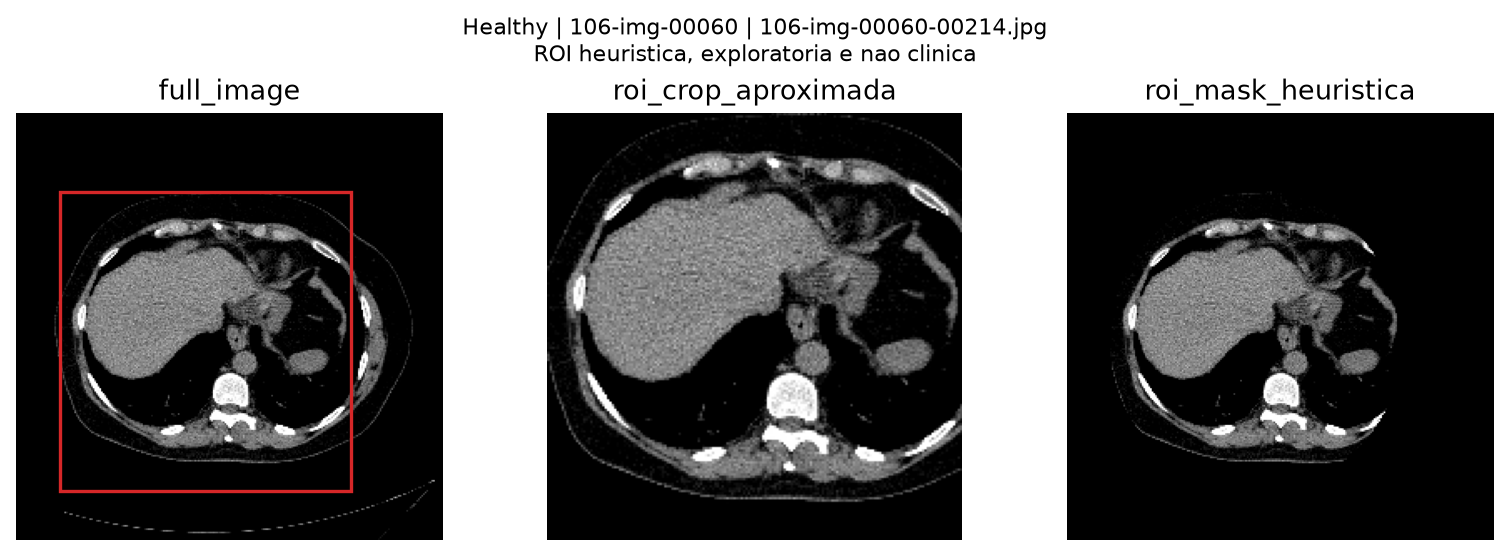

roi_example_00_Hepatic_Steatosis_117-img-00066_117-img-00066-00031.png


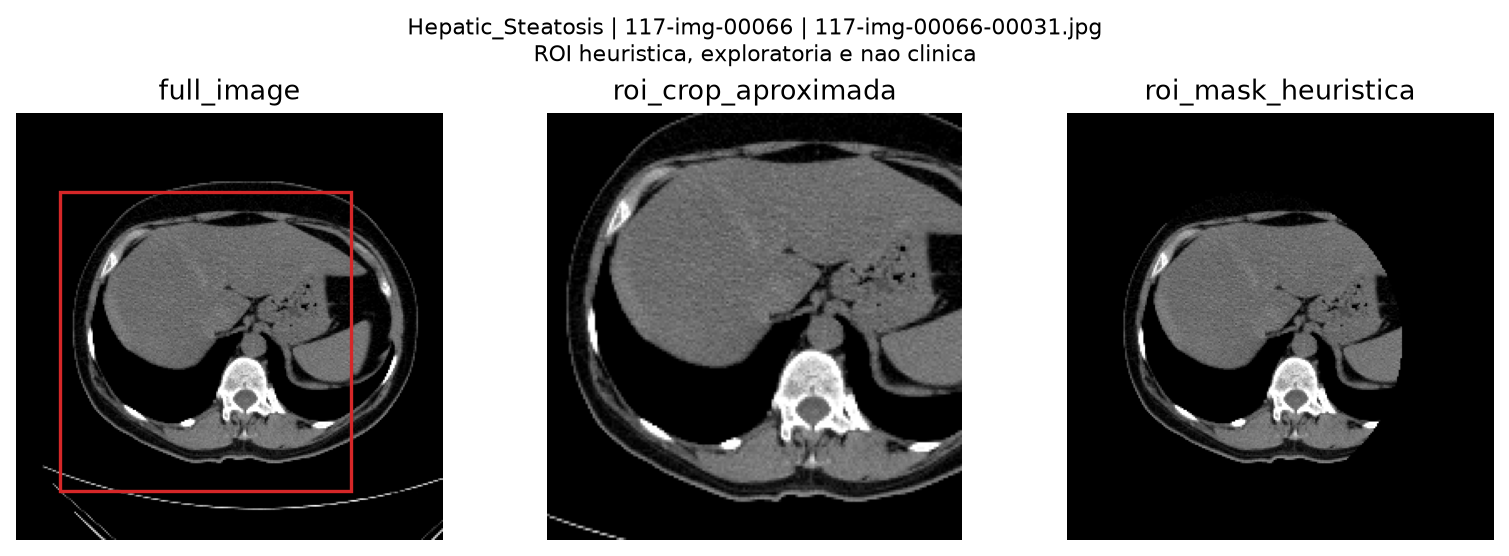

roi_example_01_Healthy_221-img-00009_221-img-00009-00021.png


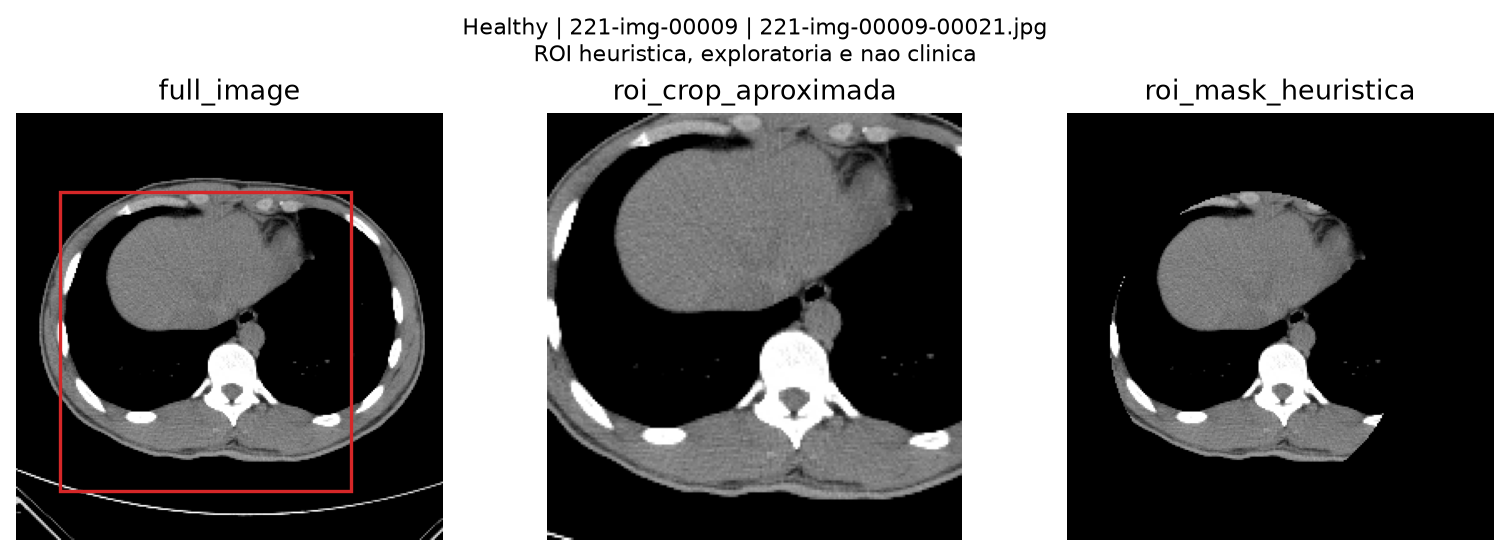

roi_example_01_Hepatic_Steatosis_126-img-00075_126-img-00075-00033.png


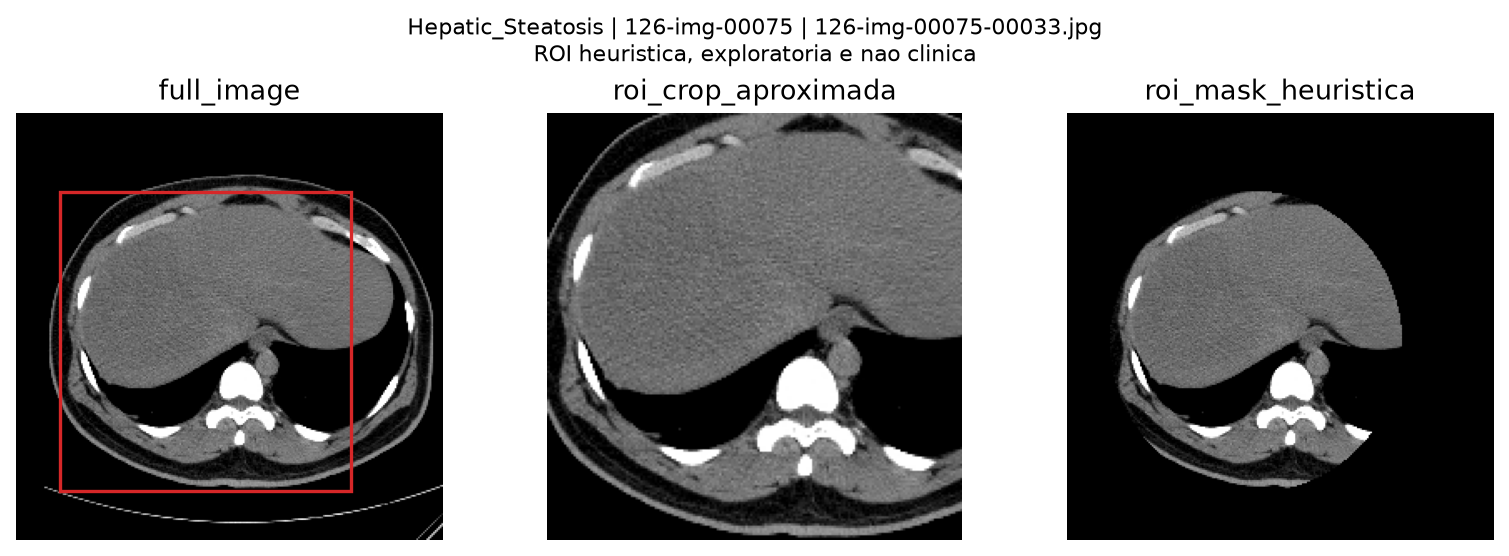

roi_example_02_Healthy_36-img-00031_36-img-00031-00202.png


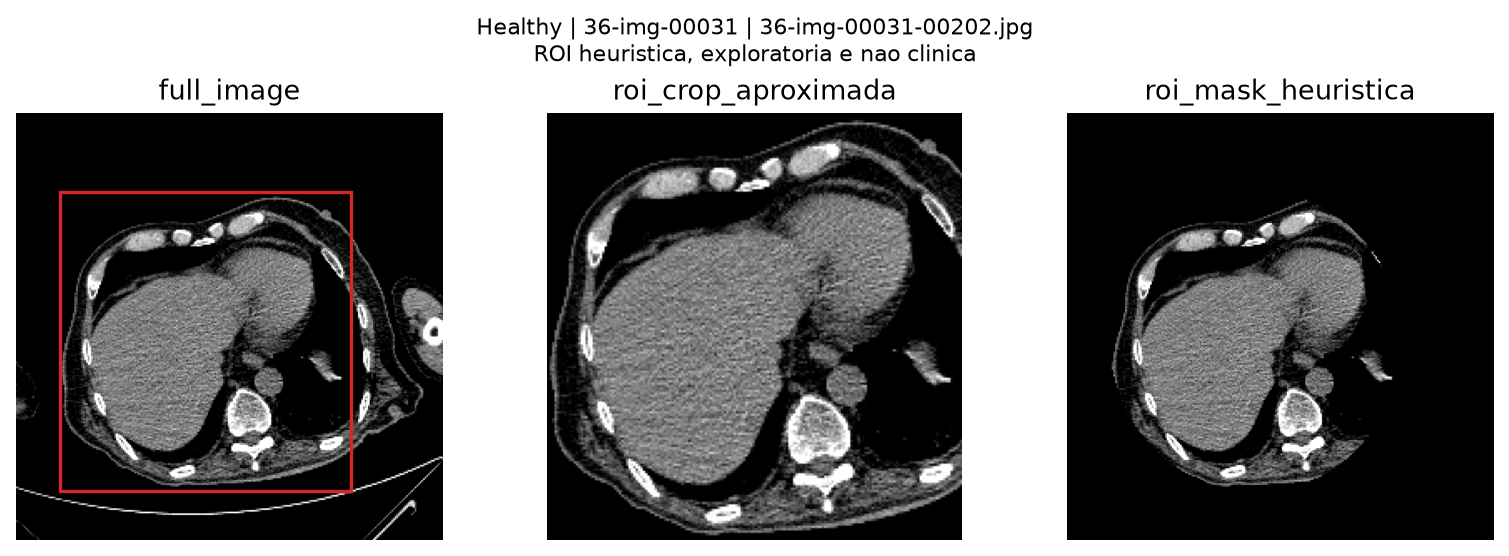

roi_example_02_Hepatic_Steatosis_131-img-00080_131-img-00080-00229.png


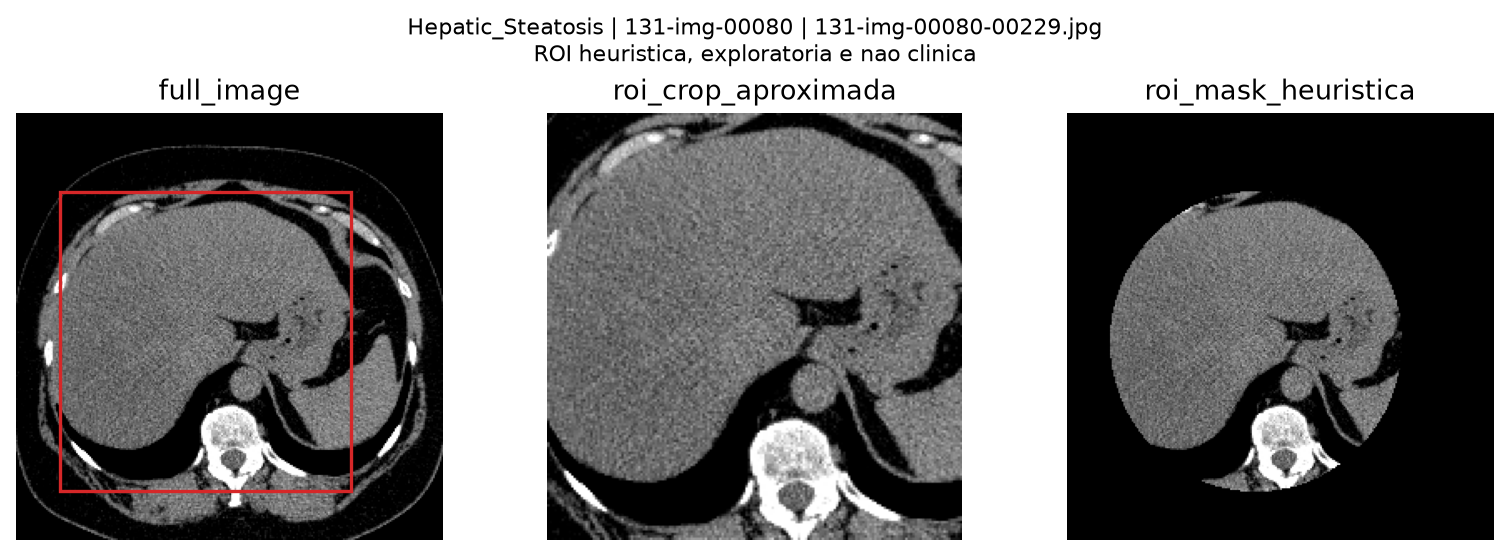

In [4]:
if ROI_EXAMPLES_DIR.exists():
    image_paths = sorted(ROI_EXAMPLES_DIR.glob("*.png"))[:6]
    if not image_paths:
        print(f"Nenhuma figura encontrada em {ROI_EXAMPLES_DIR}")
    for image_path in image_paths:
        print(image_path.name)
        display(Image(filename=str(image_path)))
else:
    print(f"Diretorio ainda nao encontrado: {ROI_EXAMPLES_DIR}")

## 6. Interpretacao esperada

Esta etapa separa analise descritiva e preditiva. A analise aqui e preditiva comparativa, com uma intervencao tecnica na entrada da imagem.

Ela nao e uma inferencia causal formal: nao ha randomizacao, mascara validada, anotacao hepatica de referencia ou controle clinico suficiente para concluir causalidade.

Tambem nao valida uso clinico. Mesmo se a ROI aproximada tiver desempenho parecido com `full_image`, isso apenas sugere que vale investigar a regiao hepatica com segmentacao adequada em etapa futura.

## 7. Proximo passo com segmentacao

O nnU-Net deve ser tratado como possivel passo futuro para segmentacao supervisionada, nao como substituto direto da CNN de classificacao.

Para testar nnU-Net corretamente, seriam necessarios dados medicos adequados, preferencialmente DICOM/NIfTI ou outro formato sem perda, alem de mascaras hepaticas de referencia. Nao se deve converter JPEG para simular DICOM/NIfTI, nem inventar mascara clinica.

Documento metodologico: `docs/experimentos_roi_e_nnunet.md`.